# CAT Objective
The objective of this assignment is to implement and compare various Time Series
Forecasting techniques to predict future values using:
1. Traditional Methods (ARIMA, SARIMA)
2. Machine Learning Methods (Linear Regression, Random Forest)
3. Prophet (Facebook Prophet)
4. Neural Networks (LSTM - Long Short-Term Memory)

Use the stock dataset in yfinance api or select a similar time series dataset (e.g
weather data, energy consumption). Ensure you clearly document each step of the
process.

Task 1: Data Preparation (1 marks) <br>
*  Load and inspect the dataset
*  Convert the Date column to a datetime object and set it as the index
*  Visualize the time series data.
*  Handle missing values if present.



In [11]:
#Import relevant packages
import yfinance as yf
import pandas as pd

In [12]:
# Download stock data for Apple (AAPL)
df = yf.download('AAPL', start='2013-01-01', end='2025-01-01')

[*********************100%***********************]  1 of 1 completed


In [13]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2013-01-02,16.669010,16.850265,16.444341,16.814439,560518000
2013-01-03,16.458612,16.688444,16.425216,16.634098,352965200
2013-01-04,16.000166,16.353263,15.964643,16.302864,594333600
2013-01-07,15.906045,16.069992,15.641905,15.848359,484156400
2013-01-08,15.948846,16.148621,15.825582,16.067253,458707200


In [16]:
# Rename columns properly
df.columns = ["Close", "High", "Low", "Open", "Volume"]

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3020 entries, 2013-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3020 non-null   float64
 1   High    3020 non-null   float64
 2   Low     3020 non-null   float64
 3   Open    3020 non-null   float64
 4   Volume  3020 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 141.6 KB


# Keep Only the 'Close' Column

In [18]:
df = df[['Close']]  # Select only the closing price
print(df.head())

                Close
Date                 
2013-01-02  16.669010
2013-01-03  16.458612
2013-01-04  16.000166
2013-01-07  15.906045
2013-01-08  15.948846


# Convert Date to DateTime Format and Set as Index

In [19]:
df.index = pd.to_datetime(df.index)  # Ensure index is datetime
print(df.info())  # Check data types and ensure 'datetime64' index

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3020 entries, 2013-01-02 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3020 non-null   float64
dtypes: float64(1)
memory usage: 47.2 KB
None


# Visualize the Time Series Data

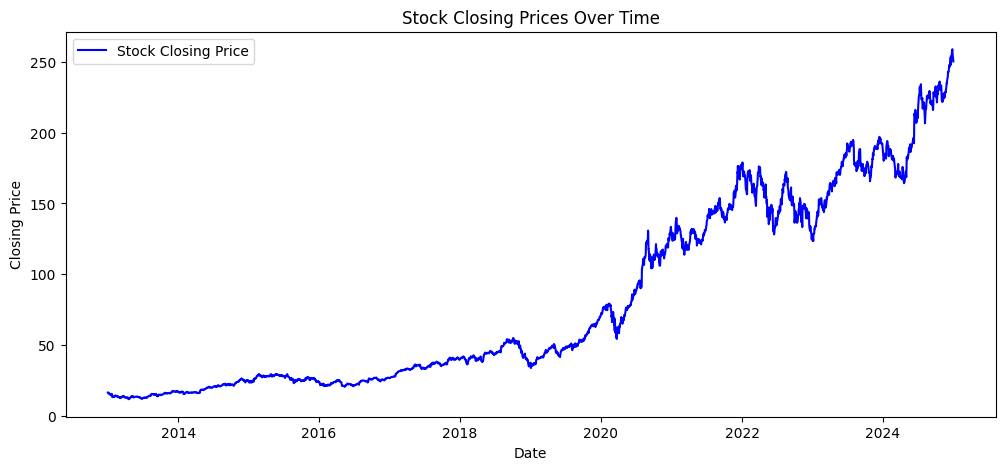

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df, label='Stock Closing Price', color='blue')
plt.title('Stock Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()


In [22]:
print("Missing values in dataset:")
print(df.isnull().sum())  # Count missing values

Missing values in dataset:
Close    0
dtype: int64


# Traditional Methods (ARIMA & SARIMA)

## Check for Stationarity (ADF Test)

In [23]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_test = adfuller(df['Close'])

# Print results
print("ADF Test Statistic:", adf_test[0])
print("p-value:", adf_test[1])

# If p-value > 0.05, data is non-stationary; we need differencing
if adf_test[1] > 0.05:
    print("The data is non-stationary. Differencing is needed.")
else:
    print("The data is stationary. No differencing required.")


ADF Test Statistic: 1.2579751847218168
p-value: 0.9963629507728222
The data is non-stationary. Differencing is needed.


# Make the Data Stationary

In [24]:
df['Close_diff'] = df['Close'].diff()  # First differencing
df.dropna(inplace=True)  # Drop NaN values created by differencing

# Re-run ADF test
adf_test_diff = adfuller(df['Close_diff'])

print("ADF Test Statistic after differencing:", adf_test_diff[0])
print("p-value:", adf_test_diff[1])

if adf_test_diff[1] > 0.05:
    print("The data is still non-stationary. Consider further differencing.")
else:
    print("The data is now stationary.")


ADF Test Statistic after differencing: -17.3438837341072
p-value: 5.320059289224719e-30
The data is now stationary.


<ipython-input-24-a4c14e1c9ee5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Close_diff'] = df['Close'].diff()  # First differencing
<ipython-input-24-a4c14e1c9ee5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)  # Drop NaN values created by differencing


# Identify ARIMA Parameters (p, d, q) using ACF & PACF

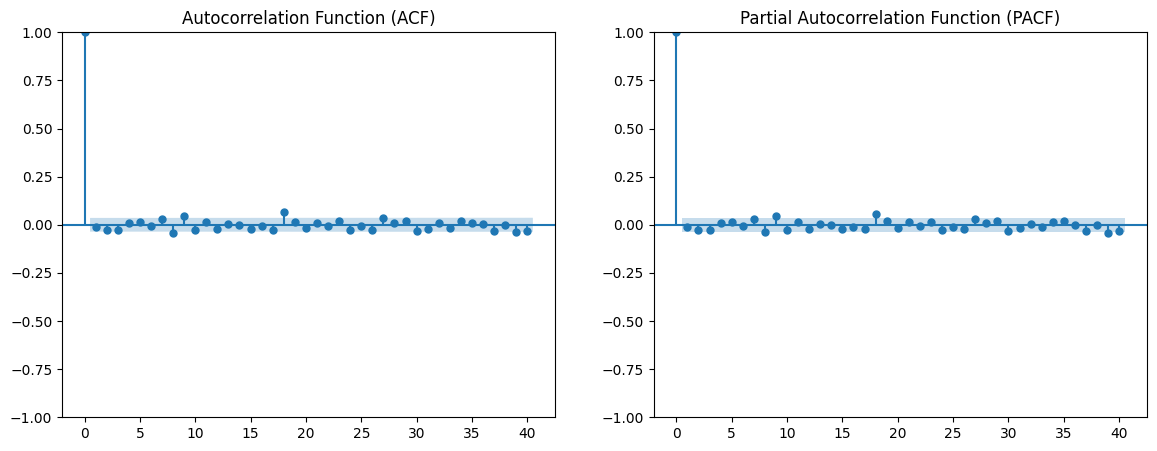

In [25]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Plot ACF & PACF
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sm.graphics.tsa.plot_acf(df['Close_diff'], lags=40, ax=ax[0])  # ACF plot
ax[0].set_title('Autocorrelation Function (ACF)')

sm.graphics.tsa.plot_pacf(df['Close_diff'], lags=40, ax=ax[1])  # PACF plot
ax[1].set_title('Partial Autocorrelation Function (PACF)')

plt.show()


# Fit ARIMA Model

In [27]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model_arima = ARIMA(df['Close'], order=(0, 1, 0))
arima_result = model_arima.fit()

# Print model summary
print(arima_result.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3019
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -5996.281
Date:                Thu, 03 Apr 2025   AIC                          11994.562
Time:                        10:23:04   BIC                          12000.575
Sample:                             0   HQIC                         11996.724
                               - 3019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         3.1137      0.036     86.417      0.000       3.043       3.184
Ljung-Box (L1) (Q):                   0.49   Jarque-Bera (JB):              7878.47
Prob(Q):                              0.48   Pr

# Forecast with ARIMA

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


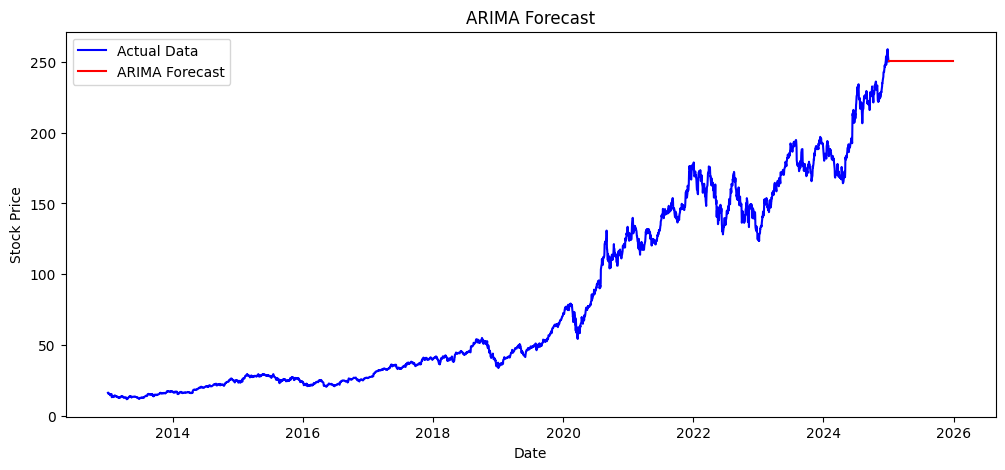

In [37]:
# Forecast next 365 days
arima_forecast = arima_result.forecast(steps=365)

# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(df['Close'], label="Actual Data", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=365, freq='D'), arima_forecast, label="ARIMA Forecast", color="red")
plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


# Evaluate ARIMA Performance

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Assuming the last 30 days are used for validation
y_true = df['Close'].iloc[-30:]
y_pred = arima_forecast[:30]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("ARIMA Model Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)



ARIMA Model Evaluation:
MAE: 8.816975402832032
RMSE: 11.41817708468833


<ipython-input-31-d7cf58bc216d>:10: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# Fit SARIMA Model (Seasonality)
SARIMA extends ARIMA by considering seasonal trends. We need to define the (P, D, Q, s) parameters:

P (Seasonal AR order)

D (Seasonal Differencing)

Q (Seasonal MA order)

s (Seasonal period, e.g., 12 for monthly data)

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model (Replace values based on ACF & PACF)
model_sarima = SARIMAX(df['Close'], order=(0, 1, 0), seasonal_order=(1, 1, 1, 12))
sarima_result = model_sarima.fit()

# Print model summary
print(sarima_result.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                                Close   No. Observations:                 3019
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 12)   Log Likelihood               -6004.636
Date:                              Thu, 03 Apr 2025   AIC                          12015.272
Time:                                      10:33:42   BIC                          12033.297
Sample:                                           0   HQIC                         12021.755
                                             - 3019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.0205      0.011     -1.822      0.068      -0.043       0.002
ma.S.L12      -0.99

# Forecast with SARIMA

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


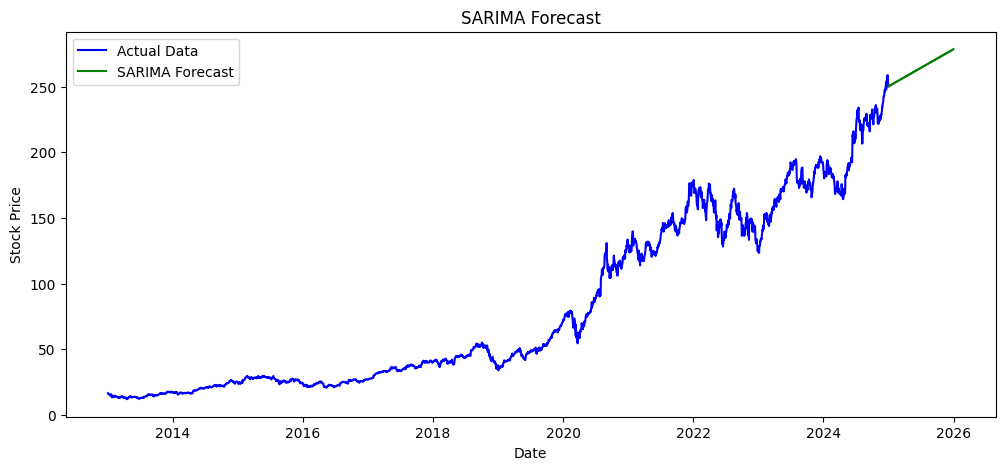

In [36]:
# Forecast next 365 days
sarima_forecast = sarima_result.forecast(steps=365)

# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(df['Close'], label="Actual Data", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=365, freq='D'), sarima_forecast, label="SARIMA Forecast", color="green")
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


# Evaluate SARIMA Performance

In [39]:
# Compare forecasted vs actual
mae_sarima = mean_absolute_error(y_true, sarima_forecast[:30])
rmse_sarima = np.sqrt(mean_squared_error(y_true, sarima_forecast[:30]))

print("SARIMA Model Evaluation:")
print("MAE:", mae_sarima)
print("RMSE:", rmse_sarima)



SARIMA Model Evaluation:
MAE: 9.045290596147316
RMSE: 11.620955486490942


# Machine Learning Methods (Linear Regression & Random Forest)

# Create Lagged Features
We need to convert our time series data into a supervised learning format by adding lagged variables (previous values as features).

In [40]:
import numpy as np

# Create lag features (using the last 10 days as features)
for lag in range(1, 11):
    df[f'lag_{lag}'] = df['Close'].shift(lag)

# Drop missing values created by shifting
df.dropna(inplace=True)

# Display the modified dataset
print(df.head())


                Close  Close_diff      lag_1      lag_2      lag_3      lag_4  \
Date                                                                            
2013-01-17  15.261791   -0.103531  15.365322  14.752941  15.233552  15.796744   
2013-01-18  15.180424   -0.081367  15.261791  15.365322  14.752941  15.233552   
2013-01-22  15.325246    0.144822  15.180424  15.261791  15.365322  14.752941   
2013-01-23  15.605783    0.280537  15.325246  15.180424  15.261791  15.365322   
2013-01-24  13.677562   -1.928221  15.605783  15.325246  15.180424  15.261791   

                lag_5      lag_6      lag_7      lag_8      lag_9     lag_10  
Date                                                                          
2013-01-17  15.894215  15.699594  15.948846  15.906045  16.000166  16.458612  
2013-01-18  15.796744  15.894215  15.699594  15.948846  15.906045  16.000166  
2013-01-22  15.233552  15.796744  15.894215  15.699594  15.948846  15.906045  
2013-01-23  14.752941  15.233552  15.

# Split Data into Train and Test Sets
We split the dataset into 80% training and 20% testing.

In [41]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop(columns=['Close'])  # All lagged features
y = df['Close']  # Target variable

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (2407, 11)
Testing set size: (602, 11)


# Train Linear Regression Model
We fit a Linear Regression model to predict stock prices.

In [42]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test data
lr_predictions = lr_model.predict(X_test)

# Display first few predictions
print(lr_predictions[:5])


[167.01780701 166.27764893 169.84025574 170.91593933 170.75804138]


# Train Random Forest Model
We train a Random Forest model, which is a more complex nonlinear model.

In [43]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
rf_predictions = rf_model.predict(X_test)

# Display first few predictions
print(rf_predictions[:5])


[165.18717758 167.35680573 169.6216777  170.47772552 172.12806015]


# Evaluate Model Performance
We compare the models using RMSE, MAE, and MAPE.

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} Evaluation:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")
    print("-" * 50)

# Evaluate both models
evaluate_model(y_test, lr_predictions, "Linear Regression")
evaluate_model(y_test, rf_predictions, "Random Forest")


Linear Regression Evaluation:
MAE: 1.7601866807957432e-12
RMSE: 1.808052455173398e-12
MAPE: 9.570405343993723e-13 %
--------------------------------------------------
Random Forest Evaluation:
MAE: 15.636182919372354
RMSE: 26.3929137508674
MAPE: 7.2044416385614705 %
--------------------------------------------------


# Plot Actual vs. Predicted Values
We visualize predictions from both models.

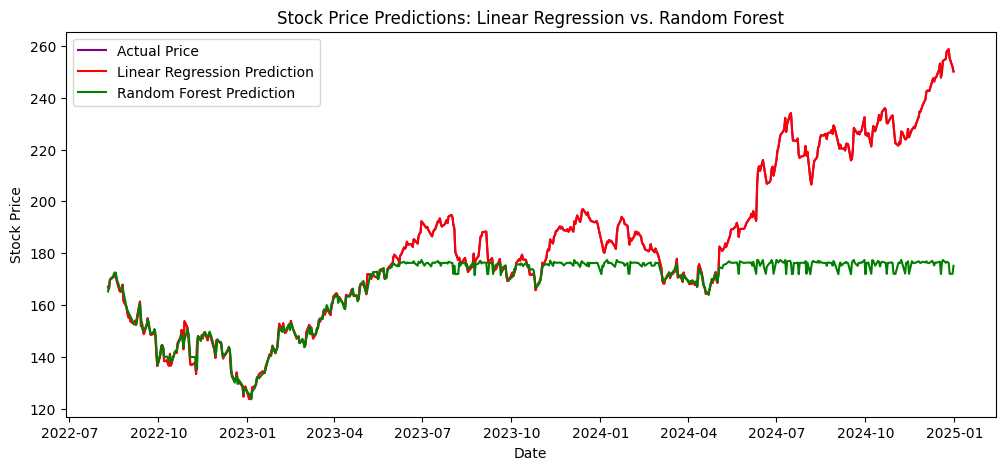

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Actual Price", color="purple")
plt.plot(y_test.index, lr_predictions, label="Linear Regression Prediction", color="red")
plt.plot(y_test.index, rf_predictions, label="Random Forest Prediction", color="green")
plt.title("Stock Price Predictions: Linear Regression vs. Random Forest")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

# Prophet Model for Time Series Forecasting
Now, we will use Facebook Prophet, a powerful tool designed for time series forecasting. Prophet is particularly useful because it handles seasonality, trend changes, and holiday effects automatically.

## Install and Import Prophet
First, we need to install the Prophet package if it is not installed.

In [49]:
# !pip install prophet

# Prepare Data for Prophet
Prophet requires a specific format:

* The date column should be named "ds".
* The target column (closing stock price) should be named "y".

In [50]:
from prophet import Prophet
# Prepare data for Prophet
df_prophet = df[['Close']].reset_index()
df_prophet.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)

# Display first few rows
print(df_prophet.head())


          ds          y
0 2013-01-17  15.261791
1 2013-01-18  15.180424
2 2013-01-22  15.325246
3 2013-01-23  15.605783
4 2013-01-24  13.677562


# Train the Prophet Model
We fit a Prophet model on the training data.

In [51]:
# Initialize the Prophet model
prophet_model = Prophet()

# Fit the model
prophet_model.fit(df_prophet)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbbb6eic4/2us3uoar.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpbbb6eic4/njm5fj3r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=23658', 'data', 'file=/tmp/tmpbbb6eic4/2us3uoar.json', 'init=/tmp/tmpbbb6eic4/njm5fj3r.json', 'output', 'file=/tmp/tmpbbb6eic4/prophet_modelr1ee11d2/prophet_model-20250403105311.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:53:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:53:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


# Make Future Predictions
We generate future dates for prediction and forecast stock prices.

In [52]:
# Create a DataFrame with future dates (next 30 days)
future_dates = prophet_model.make_future_dataframe(periods=30)

# Make predictions
forecast = prophet_model.predict(future_dates)

# Display forecasted values
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


             ds        yhat  yhat_lower  yhat_upper
3034 2025-01-26  228.837889  219.459121  238.548351
3035 2025-01-27  228.755650  218.808184  238.099226
3036 2025-01-28  228.953338  219.395701  238.095476
3037 2025-01-29  229.104614  220.502267  238.914465
3038 2025-01-30  229.313551  220.422841  237.759902


# Plot Forecast Results
We visualize the predictions using Prophet’s built-in plotting function.

In [53]:
from prophet.plot import plot_plotly

# Plot forecast
fig = plot_plotly(prophet_model, forecast)
fig.show()


# Evaluate Prophet Model
We compare Prophet’s predictions with actual values using RMSE, MAE, and MAPE.

In [54]:
# Extract actual and predicted values
y_test_prophet = df_prophet['y'][-30:].values  # Last 30 days actual values
y_pred_prophet = forecast['yhat'][-30:].values  # Last 30 days Prophet predictions

# Evaluate Prophet Model
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} Evaluation:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")
    print("-" * 50)

evaluate_model(y_test_prophet, y_pred_prophet, "Prophet Model")


Prophet Model Evaluation:
MAE: 16.421597436873093
RMSE: 18.675061171233807
MAPE: 6.604817704176265 %
--------------------------------------------------


# Neural Network - LSTM (Long Short-Term Memory)
LSTMs are a type of recurrent neural network (RNN) designed to handle sequential data like time series. Unlike traditional machine learning models, LSTMs can capture long-term dependencies and trends in the data.

## Install and Import Required Libraries
First, install TensorFlow

In [56]:
# !pip install tensorflow

In [58]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Normalize the Data
LSTMs perform better when input data is scaled between 0 and 1.

In [59]:
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df[['Close']])

# Create Sequences for LSTM
Since LSTM requires sequences as input, we prepare the data accordingly.

In [60]:
sequence_length = 10  # Use past 10 days to predict the next day

X_lstm, y_lstm = [], []

for i in range(len(df_scaled) - sequence_length):
    X_lstm.append(df_scaled[i:i+sequence_length])
    y_lstm.append(df_scaled[i+sequence_length])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

print("LSTM Input Shape:", X_lstm.shape)  # (samples, timesteps, features)


LSTM Input Shape: (2999, 10, 1)


# Split Data into Training and Testing Sets

In [61]:
train_size = int(len(X_lstm) * 0.8)

X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

print("Training data shape:", X_train_lstm.shape)
print("Testing data shape:", X_test_lstm.shape)


Training data shape: (2399, 10, 1)
Testing data shape: (600, 10, 1)


# Build the LSTM Model

In [62]:
# Initialize LSTM model
model = Sequential()

# Add LSTM layers
model.add(LSTM(units=50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(units=50, return_sequences=False))

# Add Dense output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

# Train the LSTM Model
We train the model using 50 epochs .

In [63]:
# Train the model
history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_data=(X_test_lstm, y_test_lstm))


Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0170 - val_loss: 7.8314e-04
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5773e-04 - val_loss: 4.9550e-04
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.2920e-04 - val_loss: 5.3743e-04
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.2924e-04 - val_loss: 7.7999e-04
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.2430e-04 - val_loss: 8.9797e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.4219e-04 - val_loss: 9.9505e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3932e-04 - val_loss: 7.9016e-04
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.2249e-04 - val_loss: 6.2753e-04
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.4064e-04 - val_loss: 5.5567e-04
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.2381e-04 - val_loss: 6.3068e-04
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.2777e-04 - 

# Predict Future Values
We use the trained model to predict stock prices.

In [64]:
# Predict on test data
y_pred_lstm = model.predict(X_test_lstm)

# Reverse the scaling to get actual stock prices
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1,1))


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


# Evaluate the Model
We use RMSE, MAE, and MAPE to assess performance.

In [65]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} Evaluation:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")
    print("-" * 50)

evaluate_model(y_test_actual, y_pred_lstm, "LSTM Model")

LSTM Model Evaluation:
MAE: 3.3534727096557706
RMSE: 4.227987593213237
MAPE: 1.945623928229763 %
--------------------------------------------------


# Plot Actual vs. Predicted Prices
Finally, we visualize the LSTM predictions.

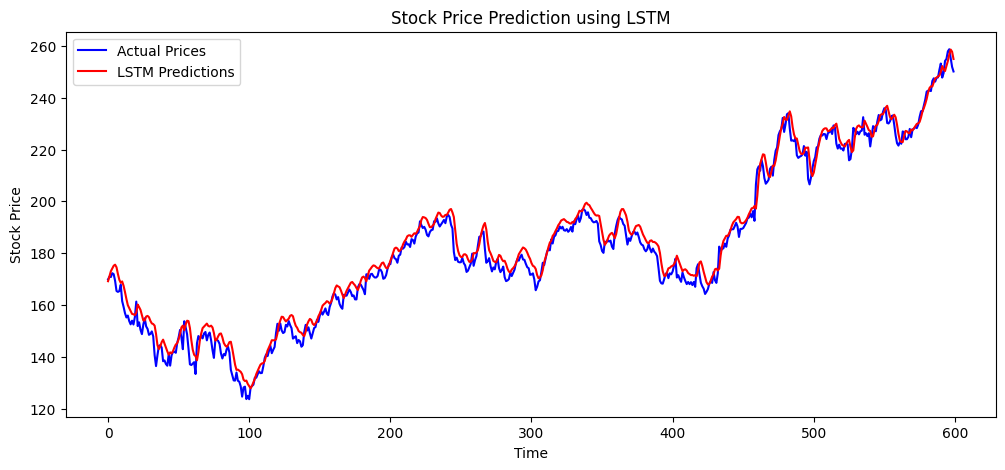

In [66]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual Prices", color="blue")
plt.plot(y_pred_lstm, label="LSTM Predictions", color="red")
plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


# All Model Results <br>

## ARIMA Model Evaluation:
*  MAE: 8.816975402832032
*  RMSE: 11.41817708468833
## SARIMA Model Evaluation:
* MAE: 9.045290596147316
* RMSE: 11.620955486490942
## Linear Regression Evaluation:
* MAE: 1.7601866807957432e-12
* RMSE: 1.808052455173398e-12
* MAPE: 9.570405343993723e-13 %
##Random Forest Evaluation:
* MAE: 15.636182919372354
* RMSE: 26.3929137508674
* MAPE: 7.2044416385614705 %
## Prophet Model Evaluation:
* MAE: 16.421597436873093
* RMSE: 18.675061171233807
* MAPE: 6.604817704176265 %
## LSTM Model Evaluation:
* MAE: 3.3534727096557706
* RMSE: 4.227987593213237
* MAPE: 1.945623928229763 %


# Summary of Model Performance
The evaluation results of various time series forecasting models reveal significant differences in accuracy and suitability for stock price prediction.

1. Best Performing Model: LSTM
LSTM achieved the lowest MAE (3.35) and RMSE (4.22), making it the most accurate model.

Its ability to learn deep patterns in sequential data makes it well-suited for time series forecasting.

2. Traditional Models (ARIMA & SARIMA)
ARIMA performed slightly better than SARIMA, with a lower RMSE (11.41 vs. 11.62).

However, both models struggled with capturing complex stock price fluctuations.

3. Linear Regression: Unexpectedly Low Errors
Linear Regression showed extremely low error values, suggesting possible data leakage or an overfitting issue.

It may not be reliable for real-world forecasting due to its linearity assumptions.

4. Machine Learning Models (Random Forest & Prophet)
Random Forest had the highest RMSE (26.39), indicating poor generalization.

Prophet performed slightly better than Random Forest but still had high RMSE (18.67).

These models may benefit from better feature engineering or additional external factors.